<a href="https://colab.research.google.com/github/homeroauto-byte/taller_K-Mean-/blob/main/notebooks/Taller_K_Mean_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Taller K _Mean**

**Manuel Gonzalez**  
**Daniel Garcia**  

##**Introduccion a la inteligencia artificial**




<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/homeroauto-byte/taller_K-Mean-/blob/main/notebooks/Taller_K_Mean_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/homeroauto-byte/taller_K-Mean-/blob/main/notebooks/Taller_K_Mean_.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>



Vamos con el preambulo de Pyton y las arandelas

In [4]:
import sys

assert sys.version_info >= (3, 10)

from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Ahora vamos con los datos  
-Base de datos de interconsultas anonimizadas-

In [8]:
import pandas as pd
import urllib.request
import json
from pathlib import Path

def load_interconsultas_data():
    # 1. Definimos la ruta local donde guardaremos el archivo
    file_path = Path("datasets/interconsultas.xlsx")

    if not file_path.is_file():
        file_path.parent.mkdir(parents=True, exist_ok=True)

        # 2. Usamos la API de GitHub para listar los archivos del repositorio
        # Esto evita errores por espacios o tildes en el nombre del archivo
        api_url = "https://api.github.com/repos/homeroauto-byte/taller_K-Mean-/contents/"

        print("Buscando el archivo en el repositorio...")
        try:
            req = urllib.request.Request(api_url, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req) as response:
                files = json.loads(response.read().decode())

            # Buscamos el archivo que termine en .xlsx
            download_url = None
            for file in files:
                if file['name'].endswith('.xlsx'):
                    download_url = file['download_url']
                    print(f"Archivo encontrado: {file['name']}")
                    break

            if not download_url:
                raise FileNotFoundError("No se encontró ningún archivo .xlsx en el repositorio.")

        except Exception as e:
            print(f"Error al conectar con la API de GitHub: {e}")
            print("Intentando con URL directa alternativa...")
            # Plan B: URL directa codificada manualmente por si la API falla
            download_url = "https://raw.githubusercontent.com/homeroauto-byte/taller_K-Mean-/main/Taller%20K%20means%20INTERCONSULTAS%20-%20TIEMPOS%20DE%20RESPUESTA.xlsx"

        # 3. Descargamos el archivo
        print(f"Descargando archivo... (esto puede tardar un poco debido al peso de 20MB)")
        try:
            urllib.request.urlretrieve(download_url, file_path)
            print("Descarga completada exitosamente.")
        except Exception as e:
            print(f"Error al descargar: {e}")
            return None

    # 4. Leemos el archivo Excel
    print("Cargando datos en Pandas...")
    return pd.read_excel(file_path)

# Ejecutamos la función
df_interconsultas = load_interconsultas_data()

# Mostramos las primeras filas para verificar
if df_interconsultas is not None:
    print("\n¡Datos cargados correctamente!")
    display(df_interconsultas.head())
else:
    print("\nNo se pudieron cargar los datos.")

Buscando el archivo en el repositorio...
Archivo encontrado: Taller K means  INTERCONSULTAS - TIEMPOS DE RESPUESTA.xlsx
Descargando archivo... (esto puede tardar un poco debido al peso de 20MB)
Descarga completada exitosamente.
Cargando datos en Pandas...

¡Datos cargados correctamente!


,FECHA_SOLICITUD,FECHA_RESPUESTA,DIAS,HORAS,ESPECIALIDAD_SOLICITADA,AREASOLICITA,TIPO_INTERCONSULTA,HCPRIINTER
0,2023-01-01 00:05:40,2023-01-01 12:25:00,0,0 days 12:19:20,CLINICA DE DOLOR,ESGE - ESTANCIA GENERAL,ANES - ANESTESIA,2
1,2023-01-01 00:29:03,2023-01-01 12:13:41,0,0 days 11:44:38,ANESTESIOLOGIA,URGN - URGENCIAS,ANES - ANESTESIA,3
2,2023-01-01 00:29:03,2023-01-03 07:35:32,2,2 days 07:06:29,MEDICINA INTERNA,URGN - URGENCIAS,GERI - GERIATRIA,3
3,2023-01-01 00:29:03,2023-01-01 12:28:01,0,0 days 11:58:58,CLINICA DE DOLOR,URGN - URGENCIAS,ANES - ANESTESIA,3
4,2023-01-01 00:55:56,2023-01-01 01:50:30,0,0 days 00:54:34,CIRUGIA GENERAL PROCEDIMIENTOS,URGN - URGENCIAS,CXGE - CIRUGIA GENERAL,2


explorar los datos

In [9]:
df_interconsultas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464533 entries, 0 to 464532
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype          
---  ------                   --------------   -----          
 0   FECHA_SOLICITUD          464533 non-null  object         
 1   FECHA_RESPUESTA          464533 non-null  object         
 2   DIAS                     464533 non-null  int64          
 3   HORAS                    464533 non-null  timedelta64[ns]
 4   ESPECIALIDAD_SOLICITADA  464533 non-null  object         
 5   AREASOLICITA             464533 non-null  object         
 6   TIPO_INTERCONSULTA       464533 non-null  object         
 7   HCPRIINTER               464533 non-null  int64          
dtypes: int64(2), object(5), timedelta64[ns](1)
memory usage: 28.4+ MB


 Exploración y Diagnóstico Inicial de Datos
### Dataset: Interconsultas Hospitalarias — Tiempos de Respuesta IC
**Objetivo:** Conocer estructura, calidad, tipos de datos y distribución de las variables categóricas antes de   el modelado.

In [22]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------------------------
# 1. INFORMACIÓN ESTRUCTURAL DEL DATAFRAME
# ----------------------------------------------------------------------------
print("=" * 70)
print("1. ESTRUCTURA DEL DATAFRAME")
print("=" * 70)
df_interconsultas.info()
print(f"\nDimensiones: {df_interconsultas.shape[0]:,} filas × {df_interconsultas.shape[1]} columnas")

# Hacemos una copia de trabajo para no modificar el original
df = df_interconsultas.copy()

# ----------------------------------------------------------------------------
# 2. FUNCIÓN DE LIMPIEZA BÁSICA DE TEXTO
#    Normaliza a mayúsculas, quita tildes y espacios duplicados.
#    Se usa aquí solo para agrupar correctamente categorías en el diagnóstico.
# ----------------------------------------------------------------------------
def limpiar(s):
    """Normaliza texto: mayúsculas, sin tildes, sin espacios dobles."""
    if pd.isna(s):
        return np.nan
    return ' '.join(
        str(s).strip().upper()
        .replace('Á', 'A').replace('É', 'E').replace('Í', 'I')
        .replace('Ó', 'O').replace('Ú', 'U').replace('Ñ', 'N')
        .split()
    )

for col in ['ESPECIALIDAD_SOLICITADA', 'AREASOLICITA', 'TIPO_INTERCONSULTA']:
    df[col] = df[col].apply(limpiar)

# Extraer códigos (lo que va antes del guion) para agrupar mejor las categorías
df['AREA_CODIGO'] = df['AREASOLICITA'].str.split(' -').str[0].str.strip()
df['TIPO_CODIGO'] = df['TIPO_INTERCONSULTA'].str.split(' -').str[0].str.strip()

# ----------------------------------------------------------------------------
# 3. CARDINALIDAD DE VARIABLES CATEGÓRICAS (por código, evita duplicados)
# ----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("2. CARDINALIDAD DE VARIABLES CATEGÓRICAS")
print("=" * 70)

print(f"\n>>> ÁREAS ÚNICAS (por código): {df['AREA_CODIGO'].nunique()}")
print(df['AREA_CODIGO'].value_counts().to_string())

print(f"\n>>> TIPOS DE INTERCONSULTA ÚNICOS (por código): {df['TIPO_CODIGO'].nunique()}")
print(df['TIPO_CODIGO'].value_counts().to_string())

print(f"\n>>> ESPECIALIDADES ÚNICAS: {df['ESPECIALIDAD_SOLICITADA'].nunique()}")
print(df['ESPECIALIDAD_SOLICITADA'].value_counts().to_string())

# ----------------------------------------------------------------------------
# 4. DIAGNÓSTICO DE FECHAS Y FORMATO
# ----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("3. DIAGNÓSTICO DE FECHAS")
print("=" * 70)
print("\nMuestra (primeras 3 filas):")
print(df[['FECHA_SOLICITUD', 'FECHA_RESPUESTA']].head(3).to_string())
print(f"\nTipo de dato FECHA_SOLICITUD: {df['FECHA_SOLICITUD'].dtype}")
print(f"Tipo de dato FECHA_RESPUESTA: {df['FECHA_RESPUESTA'].dtype}")

# Detección de valores corruptos tipo #VALUE!, N/A, None, etc.
for col in ['FECHA_SOLICITUD', 'FECHA_RESPUESTA']:
    errores = df[col].astype(str).str.contains('#|N/A|None|nan', case=False, na=False).sum()
    print(f"  {col} con valores corruptos (#, N/A, None): {errores}")

# ----------------------------------------------------------------------------
# 5. DIAGNÓSTICO DE LA VARIABLE TIEMPO (HORAS como timedelta)
# ----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("4. DIAGNÓSTICO DE TIEMPO (columna HORAS)")
print("=" * 70)
horas_num = df['HORAS'].dt.total_seconds() / 3600
print(horas_num.describe().round(3))
print(f"\n  Tiempos negativos (inconsistencias): {(horas_num < 0).sum()}")
print(f"  Tiempos > 30 días (>720h):           {(horas_num > 720).sum()}")

# Comparar DIAS vs HORAS/24 para ver si son redundantes
print("\n### ¿Son DIAS y HORAS redundantes? ###")
print(pd.DataFrame({
    'DIAS':      df['DIAS'],
    'HORAS/24':  horas_num / 24,
    'DIF_abs':   (df['DIAS'] - horas_num / 24).abs()
}).describe().round(4))

# ----------------------------------------------------------------------------
# 6. DIAGNÓSTICO DE LA PRIORIDAD (HCPRIINTER)
# ----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("5. DISTRIBUCIÓN DE PRIORIDAD (HCPRIINTER)")
print("=" * 70)
print(df['HCPRIINTER'].value_counts().sort_index().to_string())
print("\n  Leyenda: 1=Normal, 2=Prioritario, 3=Urgente")

# ----------------------------------------------------------------------------
# 7. CALIDAD DE DATOS: NULOS Y DUPLICADOS
# ----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("6. CALIDAD DE DATOS")
print("=" * 70)
print("\nValores nulos por columna:")
print(df.isna().sum().to_string())
print(f"\nFilas duplicadas exactas: {df.duplicated().sum()}")

# ----------------------------------------------------------------------------
# 8. RESUMEN EJECUTIVO
# ----------------------------------------------------------------------------
resumen = {
    'Registros totales':       f"{len(df):,}",
    'Columnas':                df.shape[1],
    'Valores nulos':           int(df.isna().sum().sum()),
    'Duplicados':              int(df.duplicated().sum()),
    'Áreas únicas':            df['AREA_CODIGO'].nunique(),
    'Tipos IC únicos':         df['TIPO_CODIGO'].nunique(),
    'Especialidades únicas':   df['ESPECIALIDAD_SOLICITADA'].nunique(),
    'Tiempo mediano (h)':      round(horas_num.median(), 2),
    'Tiempo medio (h)':        round(horas_num.mean(), 2),
    'Tiempo máx (h)':          round(horas_num.max(), 2),
}
pd.DataFrame(resumen, index=['Valor']).T

1. ESTRUCTURA DEL DATAFRAME
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464533 entries, 0 to 464532
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype          
---  ------                   --------------   -----          
 0   FECHA_SOLICITUD          464533 non-null  object         
 1   FECHA_RESPUESTA          464533 non-null  object         
 2   DIAS                     464533 non-null  int64          
 3   HORAS                    464533 non-null  timedelta64[ns]
 4   ESPECIALIDAD_SOLICITADA  464533 non-null  object         
 5   AREASOLICITA             464533 non-null  object         
 6   TIPO_INTERCONSULTA       464533 non-null  object         
 7   HCPRIINTER               464533 non-null  int64          
dtypes: int64(2), object(5), timedelta64[ns](1)
memory usage: 28.4+ MB

Dimensiones: 464,533 filas × 8 columnas

2. CARDINALIDAD DE VARIABLES CATEGÓRICAS

>>> ÁREAS ÚNICAS (por código): 28
AREA_CODIGO
ESGE      235685
URGN      1783

,Valor
Registros totales,"464,533"
Columnas,10
Valores nulos,0
Duplicados,0
Áreas únicas,28
Tipos IC únicos,69
Especialidades únicas,116
Tiempo mediano (h),3.18
Tiempo medio (h),8.2
Tiempo máx (h),799.32


##  — Exploración Visual Inicial (datos crudos)


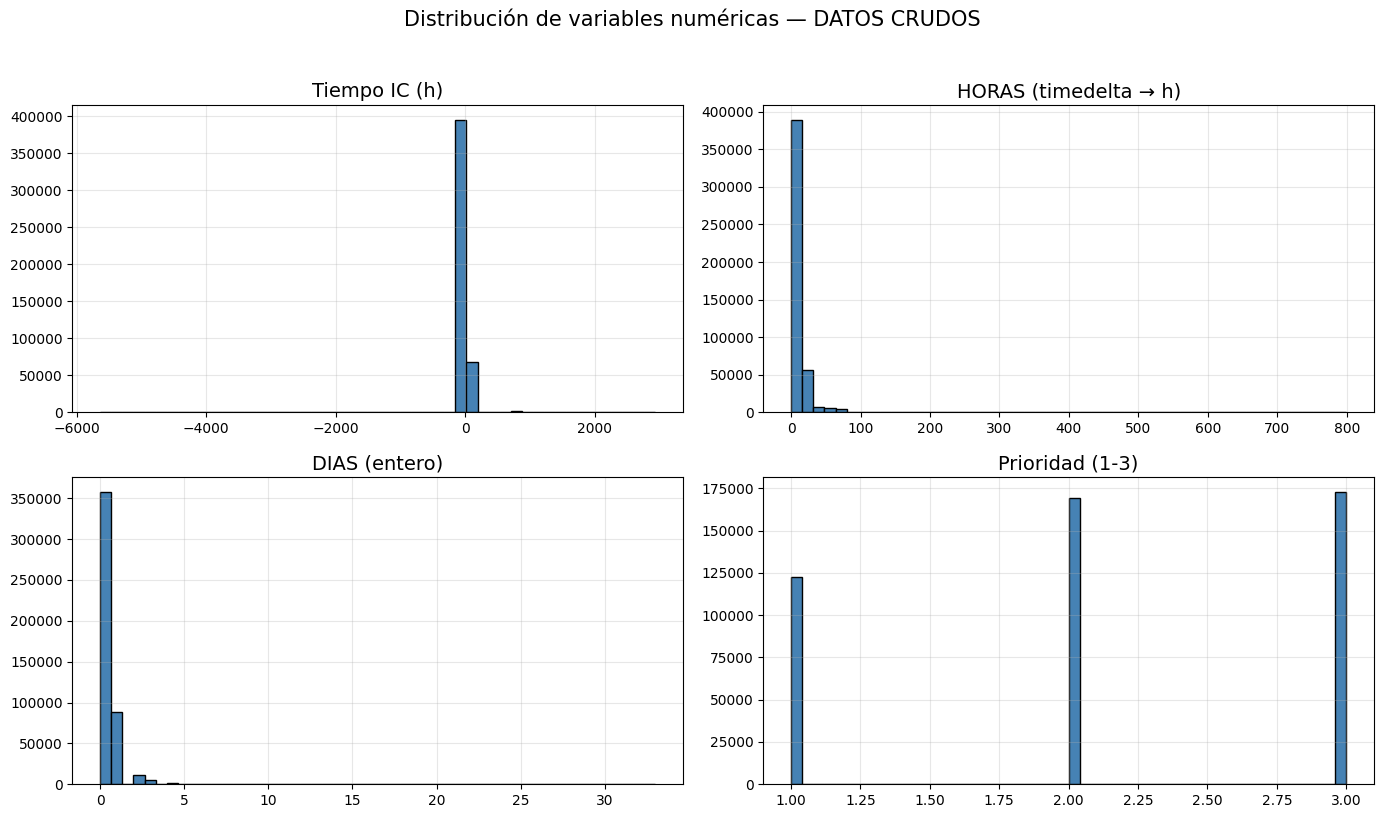

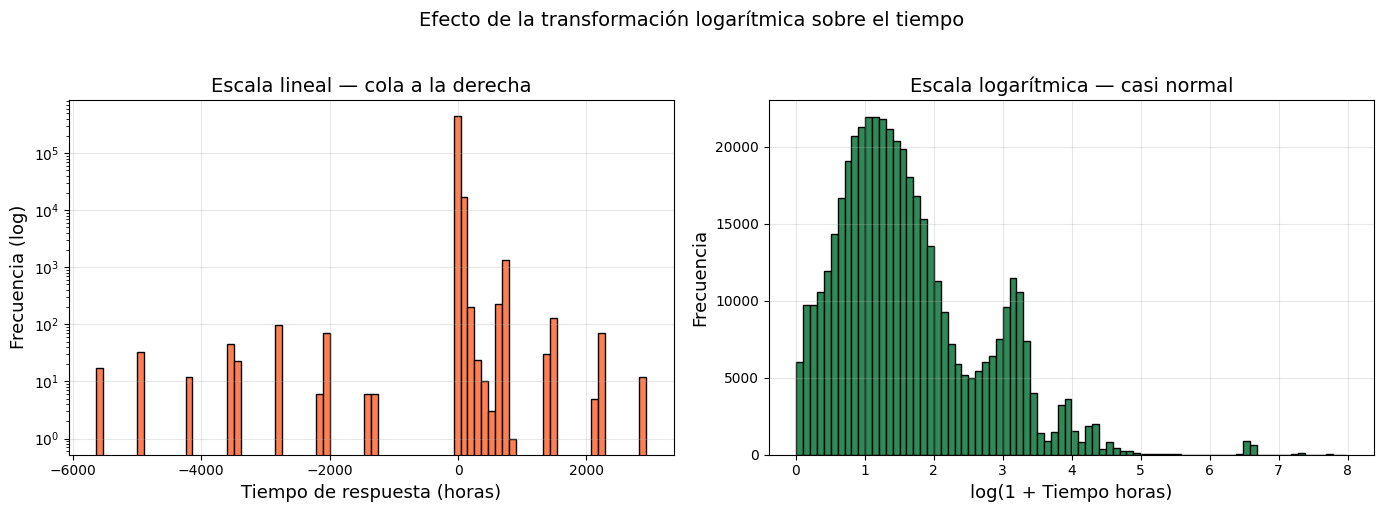

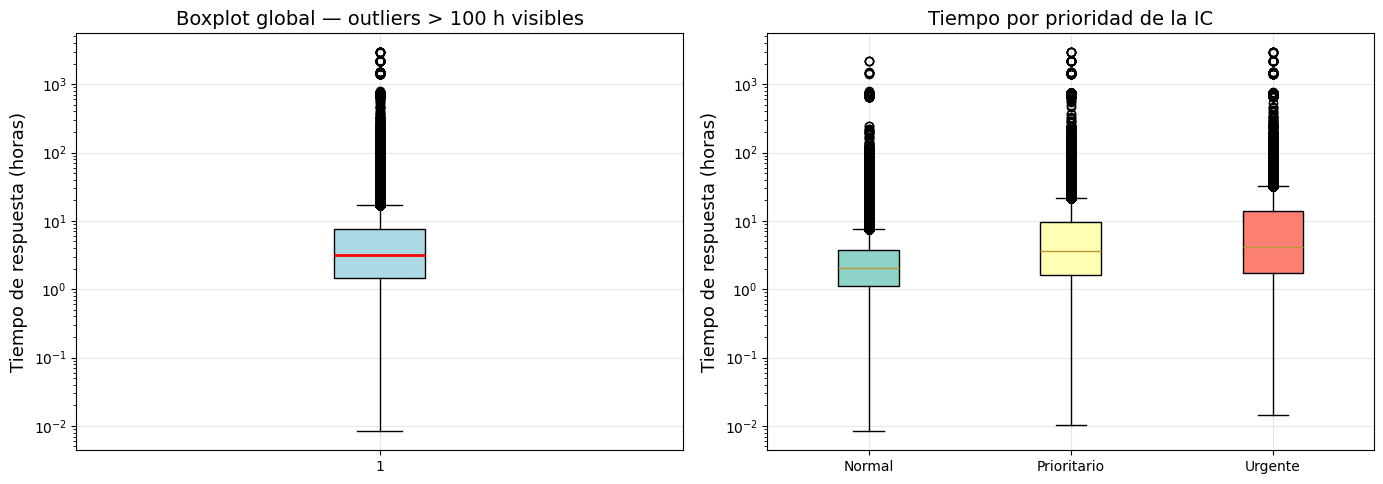

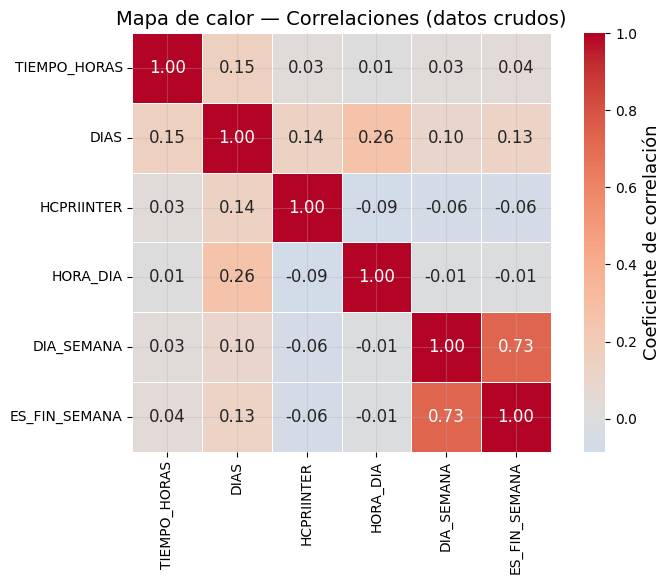

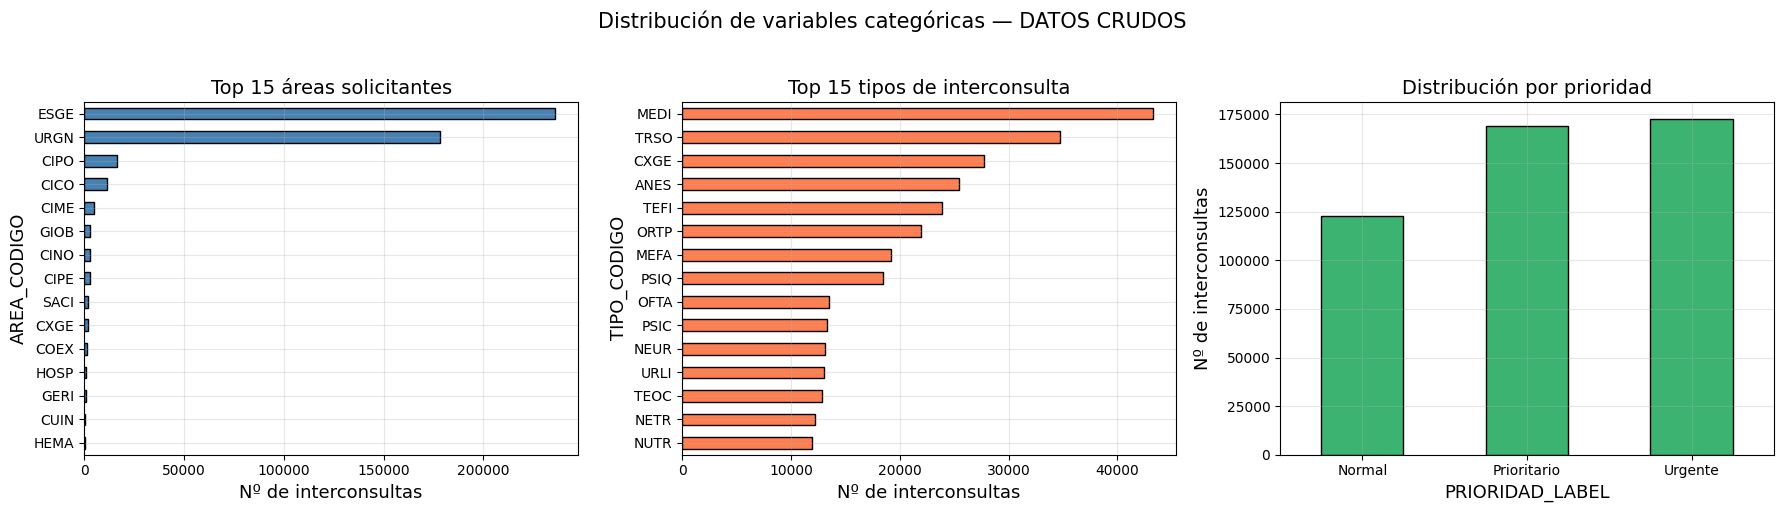

🔍 HALLAZGOS CLAVE DE LA EXPLORACIÓN VISUAL
  • Tiempo medio:    9.30 h
  • Tiempo mediano:  3.17 h
  • Tiempo máx:      2931.67 h (122.2 días)
  • Asimetría:       -21.11  →  justifica log-transform
  • Outliers > 100h: 2,916 registros
  • Área dominante:  ESGE (235,685 casos)
  • IC más frecuente:MEDI (43,230 casos)
Umbral >  1 días:  elimina  40,477 IC ( 8.71%)
Umbral >  2 días:  elimina  14,268 IC ( 3.07%)
Umbral >  3 días:  elimina   6,347 IC ( 1.37%)
Umbral >  4 días:  elimina   3,320 IC ( 0.71%)
Umbral >  5 días:  elimina   2,411 IC ( 0.52%)
Umbral >  7 días:  elimina   1,973 IC ( 0.42%)
Umbral > 10 días:  elimina   1,872 IC ( 0.40%)


In [28]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------------
# 0. CONFIGURACIÓN GLOBAL DE ESTILO (aplica a TODOS los gráficos del proyecto)
# ----------------------------------------------------------------------------
plt.rc('font', size=12)
plt.rc('axes', labelsize=13, titlesize=14)
plt.rc('legend', fontsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rcParams['figure.dpi']   = 100
plt.rcParams['axes.grid']    = True
plt.rcParams['grid.alpha']   = 0.3
sns.set_palette("husl")

# ----------------------------------------------------------------------------
# 1. PREPARACIÓN DE VARIABLES DERIVADAS PARA EL DIAGNÓSTICO
# ----------------------------------------------------------------------------
df = df_interconsultas.copy()

# Fechas
df['FECHA_SOLICITUD'] = pd.to_datetime(df['FECHA_SOLICITUD'], errors='coerce', dayfirst=True)
df['FECHA_RESPUESTA'] = pd.to_datetime(df['FECHA_RESPUESTA'], errors='coerce', dayfirst=True)

# Tiempo de respuesta en horas
df['TIEMPO_HORAS'] = (
    df['FECHA_RESPUESTA'] - df['FECHA_SOLICITUD']
).dt.total_seconds() / 3600

# HORAS (columna original timedelta) → horas numéricas
df['HORAS_NUM'] = df['HORAS'].dt.total_seconds() / 3600

# Códigos de categorías para gráficos de barras
df['AREA_CODIGO'] = df['AREASOLICITA'].str.split(' -').str[0].str.strip()
df['TIPO_CODIGO'] = df['TIPO_INTERCONSULTA'].str.split(' -').str[0].str.strip()

# Prioridad legible
df['PRIORIDAD_LABEL'] = df['HCPRIINTER'].map({1: 'Normal', 2: 'Prioritario', 3: 'Urgente'})

# ----------------------------------------------------------------------------
# 2. HISTOGRAMAS DE VARIABLES NUMÉRICAS (escala lineal)
# ----------------------------------------------------------------------------
num_df = df[['TIEMPO_HORAS', 'HORAS_NUM', 'DIAS', 'HCPRIINTER']].copy()
num_df.columns = ['Tiempo IC (h)', 'HORAS (timedelta → h)', 'DIAS (entero)', 'Prioridad (1-3)']

num_df.hist(bins=50, figsize=(14, 8), color='steelblue', edgecolor='black')
plt.suptitle('Distribución de variables numéricas — DATOS CRUDOS',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 3. HISTOGRAMAS EN ESCALA LOGARÍTMICA (para ver mejor la cola)
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tiempo crudo
axes[0].hist(df['TIEMPO_HORAS'].dropna(), bins=80,
             color='coral', edgecolor='black')
axes[0].set_xlabel('Tiempo de respuesta (horas)')
axes[0].set_ylabel('Frecuencia (log)')
axes[0].set_title('Escala lineal — cola a la derecha')
axes[0].set_yscale('log')

# Log del tiempo
log_t = np.log1p(df['TIEMPO_HORAS'].dropna())
axes[1].hist(log_t, bins=80, color='seagreen', edgecolor='black')
axes[1].set_xlabel('log(1 + Tiempo horas)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Escala logarítmica — casi normal')

plt.suptitle('Efecto de la transformación logarítmica sobre el tiempo',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 4. BOXPLOTS — Detección visual de outliers y comparación por prioridad
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4.1 Boxplot global del tiempo
axes[0].boxplot(df['TIEMPO_HORAS'].dropna(),
                vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_ylabel('Tiempo de respuesta (horas)')
axes[0].set_title('Boxplot global — outliers > 100 h visibles')
axes[0].set_yscale('log')

# 4.2 Boxplot por prioridad
data_by_priority = [
    df[df['HCPRIINTER'] == i]['TIEMPO_HORAS'].dropna()
    for i in [1, 2, 3]
]
bp = axes[1].boxplot(data_by_priority,
                     labels=['Normal', 'Prioritario', 'Urgente'],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], ['#8dd3c7', '#ffffb3', '#fb8072']):
    patch.set_facecolor(color)
axes[1].set_ylabel('Tiempo de respuesta (horas)')
axes[1].set_title('Tiempo por prioridad de la IC')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 5. MAPA DE CALOR — Correlaciones entre variables numéricas
# ----------------------------------------------------------------------------
corr_df = df[['TIEMPO_HORAS', 'DIAS', 'HCPRIINTER']].copy()
corr_df['HORA_DIA']      = df['FECHA_SOLICITUD'].dt.hour
corr_df['DIA_SEMANA']    = df['FECHA_SOLICITUD'].dt.dayofweek
corr_df['ES_FIN_SEMANA'] = (corr_df['DIA_SEMANA'] >= 5).astype(int)

corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'label': 'Coeficiente de correlación'})
plt.title('Mapa de calor — Correlaciones (datos crudos)')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 6. DISTRIBUCIÓN DE CATEGÓRICAS PRINCIPALES (Top 15 + Prioridad)
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 6.1 Top 15 áreas
top_areas = df['AREA_CODIGO'].value_counts().head(15)
top_areas.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Nº de interconsultas')
axes[0].set_title('Top 15 áreas solicitantes')
axes[0].invert_yaxis()

# 6.2 Top 15 tipos de IC
top_tipos = df['TIPO_CODIGO'].value_counts().head(15)
top_tipos.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_xlabel('Nº de interconsultas')
axes[1].set_title('Top 15 tipos de interconsulta')
axes[1].invert_yaxis()

# 6.3 Prioridad
prioridad_counts = df['PRIORIDAD_LABEL'].value_counts().reindex(['Normal', 'Prioritario', 'Urgente'])
prioridad_counts.plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='black')
axes[2].set_ylabel('Nº de interconsultas')
axes[2].set_title('Distribución por prioridad')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Distribución de variables categóricas — DATOS CRUDOS',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 7. RESUMEN DE HALLAZGOS CLAVE
# ----------------------------------------------------------------------------
print("=" * 70)
print("🔍 HALLAZGOS CLAVE DE LA EXPLORACIÓN VISUAL")
print("=" * 70)
print(f"  • Tiempo medio:    {df['TIEMPO_HORAS'].mean():.2f} h")
print(f"  • Tiempo mediano:  {df['TIEMPO_HORAS'].median():.2f} h")
print(f"  • Tiempo máx:      {df['TIEMPO_HORAS'].max():.2f} h ({df['TIEMPO_HORAS'].max()/24:.1f} días)")
print(f"  • Asimetría:       {df['TIEMPO_HORAS'].skew():.2f}  →  justifica log-transform")
print(f"  • Outliers > 100h: {(df['TIEMPO_HORAS'] > 100).sum():,} registros")
print(f"  • Área dominante:  {df['AREA_CODIGO'].mode()[0]} "
      f"({df['AREA_CODIGO'].value_counts().iloc[0]:,} casos)")
print(f"  • IC más frecuente:{df['TIPO_CODIGO'].mode()[0]} "
      f"({df['TIPO_CODIGO'].value_counts().iloc[0]:,} casos)")
print("=" * 70)
for dias in [1, 2, 3, 4, 5, 7, 10]:
    n_out = (df_original['TIEMPO_HORAS'] > dias*24).sum()
    pct   = 100 * n_out / len(df_original)
    print(f"Umbral > {dias:>2} días:  elimina {n_out:>7,} IC ({pct:>5.2f}%)")

## Limpieza Profunda y Homologación Final

### Objetivo
Dejar el dataset de interconsultas listo garantizando:
- Consistencia de tipos de datos
- Calidad y completitud de la información
- Homogeneidad de categorías

| # | Decisión | Justificación |
|---|----------|---------------|
| 1 | **Convertir fechas a `datetime` con `dayfirst=True`** | Formato original `dd/mm/yyyy HH:MM`; sin esto no se pueden calcular diferencias temporales. |
| 2 | **Calcular `TIEMPO_HORAS` desde las fechas, no desde `HORAS`** | Variable independiente y validable. Diferencia media vs columna `HORAS` ≈ 0.0003 h (consistente). |
| 3 | **Separar IC > 2 días (48 horas = 3.07% de los datos) en `df_slow`** | La exploracion anterior  mostró cola larga hasta 799 h (33 días). Estas IC son casos atípicos  Se conservan aparte para análisis complementario. |
| 4 | **Filtrar `df` a [0, 2 días]** | Mejora la interpretabilidad de los clusters operativos. Se pierde menos del  3.07%1% de los datos. |
| 5 | **Eliminar duplicados exactos** | Robustez del dataset. |
| 6 | **Normalizar texto: mayúsculas, sin tildes, espacios simples** | Corrige duplicados ocultos tipo `ESGE -  ESTANCIA GENERAL` (doble espacio) vs `ESGE - ESTANCIA GENERAL`. |
| 7 | **Separar código y nombre en `AREA` y `TIPO`** | El formato es `CÓDIGO - Descripción`. Separarlos permite trabajar con el código (compacto) y conservar el nombre legible. |
| 8 | **Extraer `ESPECIALIDAD` sin prefijo de código** | Se limpia el prefijo tipo `MEDI - ` para tener la especialidad pura. |
| 9 | **Convertir `HCPRIINTER` a categórica ordinal legible** | 1 = Normal, 2 = Prioritario, 3 = Urgente. Se crean dummies `ES_URGENTE` y `ES_PRIORITARIO` para features. |
| 10 | **Crear variables temporales** (`ANIO`, `MES`, `DIA_SEMANA`, `HORA_DIA`, `ES_FIN_SEMANA`, `ES_NOCTURNO`) | Capturan patrones de solicitud (nocturno, fin de semana) útiles para K-Means. |
| 11 | **Aplicar `LOG_TIEMPO = log1p(TIEMPO_HORAS)`** | Asimetría severa (skew > 5). El logaritmo normaliza y estabiliza la varianza. |
| 12 | **Agrupar categorías raras (< 500 casos) en `OTRAS` / `OTROS`** | 28 áreas y 69 tipos, pero solo ~14 y ~50 concentran el 99%. Reduce dimensionalidad sin perder información. |





🧹 SECCIÓN 1 — LIMPIEZA Y HOMOLOGACIÓN
Filas iniciales: 464,533

  ✗ Eliminadas por fechas inválidas:                     0
  ✓ Diferencia media vs columna HORAS:            5.4497 h
  ⚠ Separadas como IC lentas (> 2 d):               14,268  (3.07%)
  ✓ Conservadas para K-Means [0, 2 d]:             449,947
  ✗ Eliminadas por duplicados exactos:                   0

✅ SECCIÓN 2 — RESUMEN Y VERIFICACIÓN DEL DATASET LIMPIO
  Filas finales (df):           449,947
  Filas IC lentas (df_slow):     14,268
  Columnas finales:                  26
  Reducción total:                3.14%
  Áreas únicas (grupo):              15 (de 28)
  Tipos IC únicos (grupo):           50 (de 69)
  Especialidades únicas:            115
  Tiempo mediano (df):            3.03 h
  Tiempo medio (df):              6.41 h
  Tiempo máximo (df):            48.00 h
  Skew del tiempo (df):            2.16
  Nulos totales:                      0
  Duplicados exactos:                 0

📊 Distribución por Área (grupo):
AR

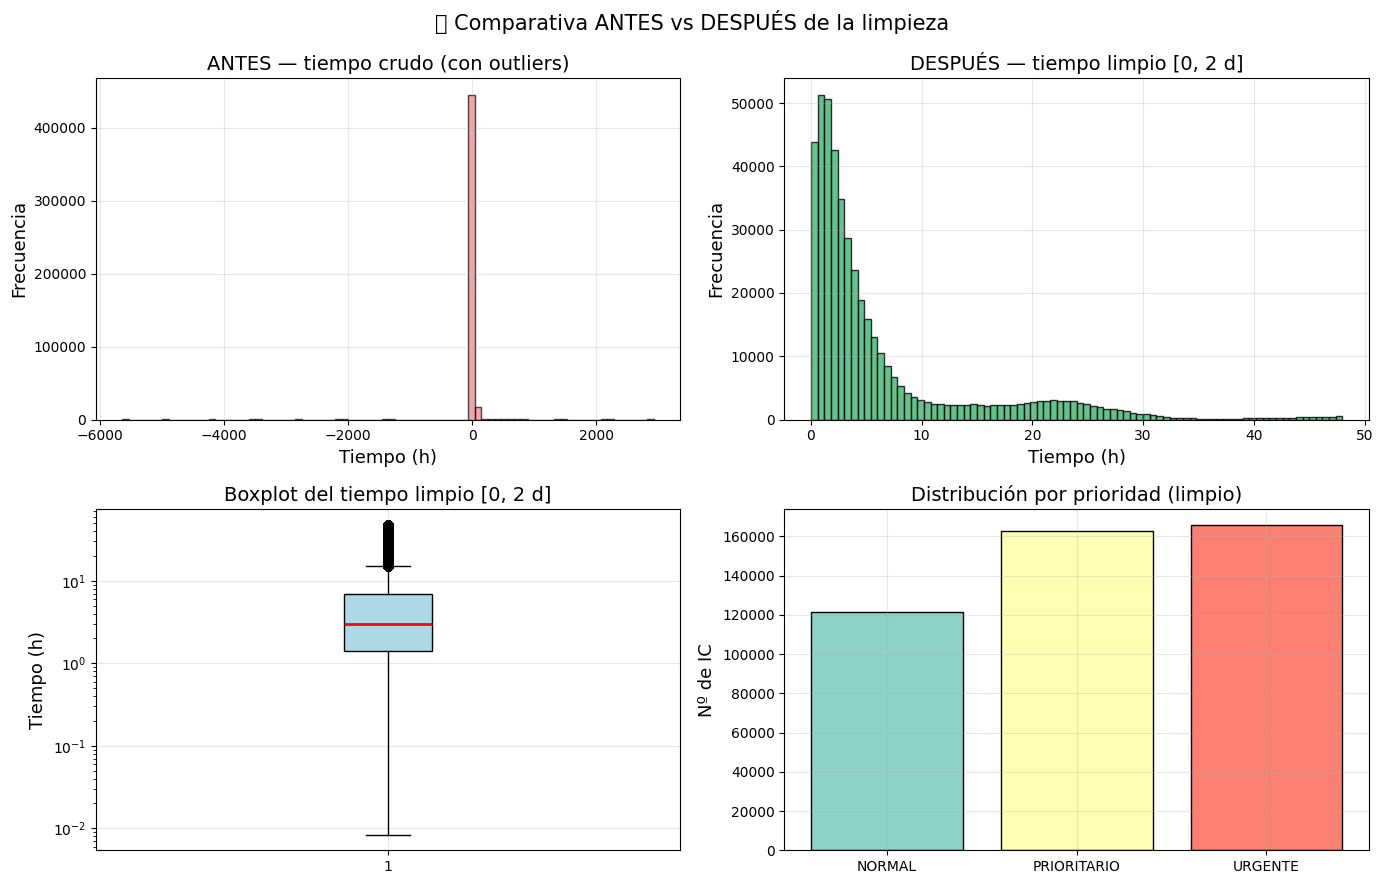

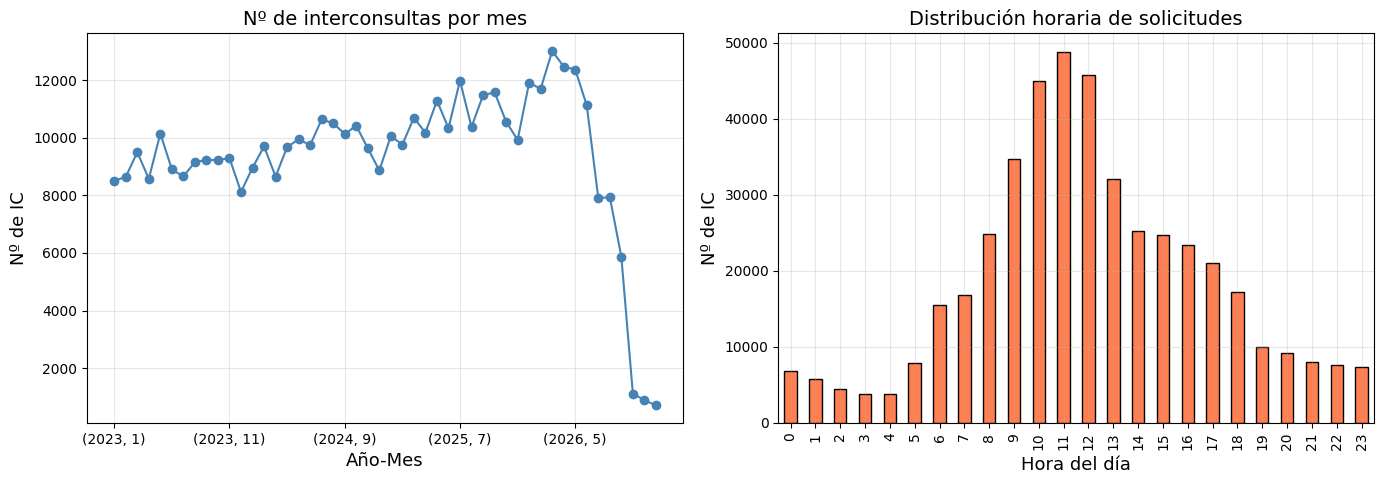

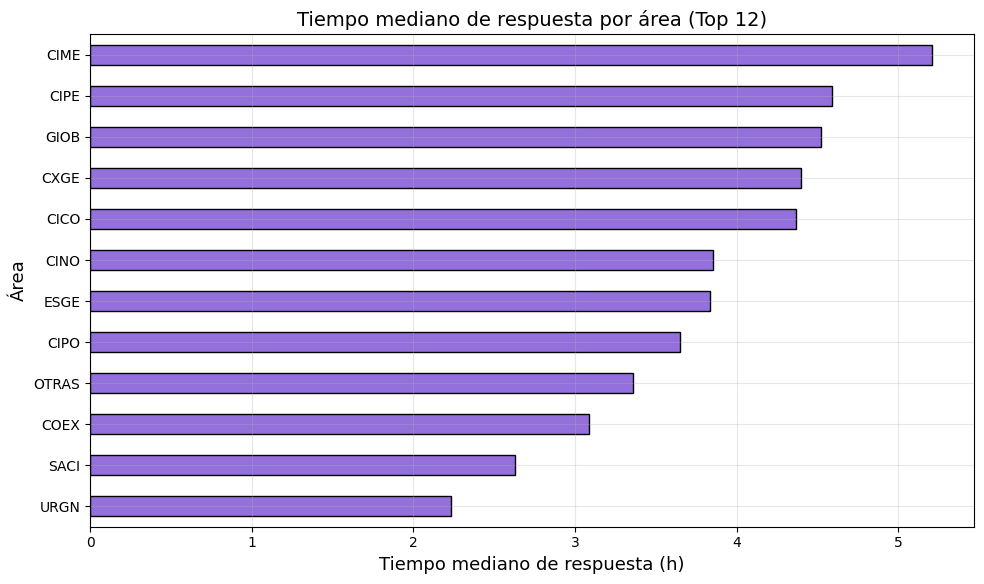


🔍 SECCIÓN 4 — IC LENTAS (> 2 días): 14,268 casos
  Tiempo mediano:  69.7 h (2.9 días)
  Tiempo máximo:   2931.7 h (122.2 días)

  📍 Top 5 áreas con IC lentas:
AREA_GRUPO
ESGE    10075
URGN     1980
CIPO      622
CICO      450
CIME      276

  📍 Top 5 tipos de IC lentas:
TIPO_GRUPO
TRSO    2760
INFE    1970
MFRE    1504
CXGE     907
PSIC     905

  📍 Distribución por prioridad:
PRIORIDAD
URGENTE        7177
PRIORITARIO    6211
NORMAL          880


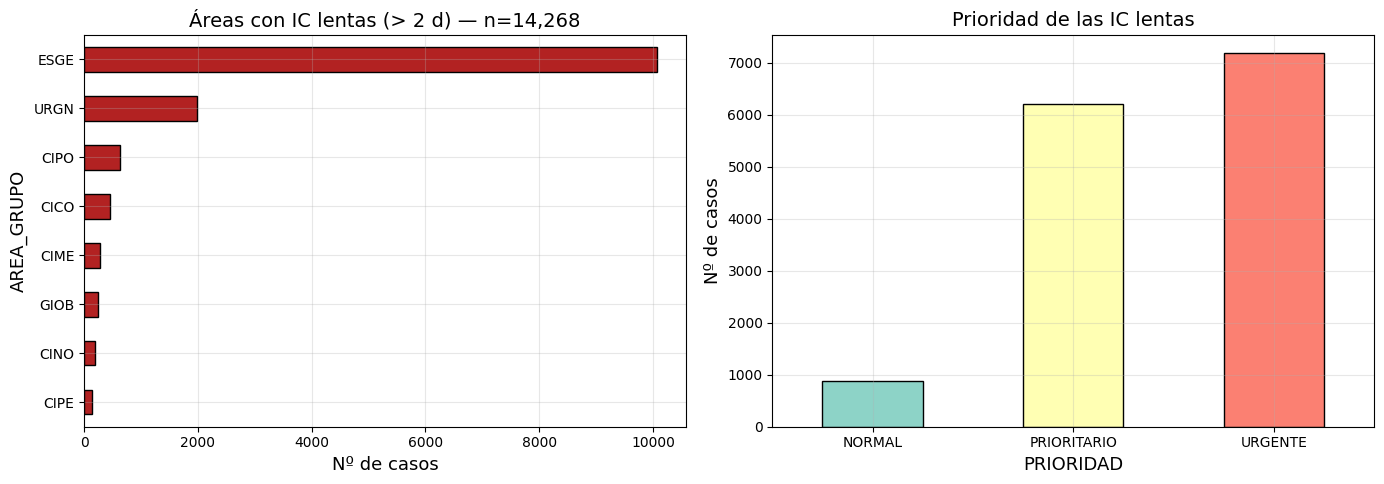


✅  — Datasets listos:
   • df      → 449,947 IC  (0 - 2 días)
   • df_slow → 14,268 IC lentas para análisis complementario


In [29]:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------------------------
# CONFIGURACIÓN GLOBAL DE ESTILO
# ----------------------------------------------------------------------------
plt.rc('font', size=12)
plt.rc('axes', labelsize=13, titlesize=14)
plt.rc('legend', fontsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rcParams['figure.dpi']  = 100
plt.rcParams['axes.grid']   = True
plt.rcParams['grid.alpha']  = 0.3
sns.set_palette("husl")

# ============================================================================
# SECCIÓN 1 — LIMPIEZA Y HOMOLOGACIÓN
# ============================================================================
df_original = df_interconsultas.copy()
df = df_interconsultas.copy()

print("=" * 70)
print("🧹 SECCIÓN 1 — LIMPIEZA Y HOMOLOGACIÓN")
print("=" * 70)
print(f"Filas iniciales: {len(df):,}\n")

# --- 1. Fechas ---
df['FECHA_SOLICITUD'] = pd.to_datetime(df['FECHA_SOLICITUD'], errors='coerce', dayfirst=True)
df['FECHA_RESPUESTA']  = pd.to_datetime(df['FECHA_RESPUESTA'],  errors='coerce', dayfirst=True)
n0 = len(df)
df = df.dropna(subset=['FECHA_SOLICITUD', 'FECHA_RESPUESTA'])
print(f"  ✗ Eliminadas por fechas inválidas:              {n0 - len(df):>8,}")

# --- 2. Tiempo en horas ---
df['TIEMPO_HORAS'] = (
    df['FECHA_RESPUESTA'] - df['FECHA_SOLICITUD']
).dt.total_seconds() / 3600
diff_validacion = (df['TIEMPO_HORAS'] - df['HORAS'].dt.total_seconds()/3600).abs()
print(f"  ✓ Diferencia media vs columna HORAS:            {diff_validacion.mean():.4f} h")

# --- 3. Filtros de calidad ---
# 3a. Separar outliers lentos (> 2 días) para análisis complementario
df_slow = df[df['TIEMPO_HORAS'] > 2 * 24].copy()
df      = df[(df['TIEMPO_HORAS'] >= 0) & (df['TIEMPO_HORAS'] <= 2 * 24)].copy()

n_total_antes_filtro = len(df) + len(df_slow)
print(f"  ⚠ Separadas como IC lentas (> 2 d):             {len(df_slow):>8,}  "
      f"({100*len(df_slow)/n_total_antes_filtro:.2f}%)")
print(f"  ✓ Conservadas para K-Means [0, 2 d]:            {len(df):>8,}")

# 3b. Duplicados
n0 = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"  ✗ Eliminadas por duplicados exactos:            {n0 - len(df):>8,}")

# --- 4. Homologación de texto ---
def limpiar(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().upper()
    for a, b in zip('ÁÉÍÓÚÑ', 'AEIOUN'):
        s = s.replace(a, b)
    return ' '.join(s.split())

for col in ['ESPECIALIDAD_SOLICITADA', 'AREASOLICITA', 'TIPO_INTERCONSULTA']:
    df[col] = df[col].apply(limpiar)
    df_slow[col] = df_slow[col].apply(limpiar)

df['AREA_CODIGO'] = df['AREASOLICITA'].str.split(' -').str[0].str.strip()
df['AREA_NOMBRE'] = df['AREASOLICITA'].str.split(' -').str[-1].str.strip()
df['TIPO_CODIGO'] = df['TIPO_INTERCONSULTA'].str.split(' -').str[0].str.strip()
df['TIPO_NOMBRE'] = df['TIPO_INTERCONSULTA'].str.split(' -').str[-1].str.strip()
df['ESPECIALIDAD'] = (df['ESPECIALIDAD_SOLICITADA']
                     .str.replace(r'^[A-Z]+ - ?', '', regex=True)
                     .str.strip())

df_slow['AREA_CODIGO'] = df_slow['AREASOLICITA'].str.split(' -').str[0].str.strip()
df_slow['TIPO_CODIGO'] = df_slow['TIPO_INTERCONSULTA'].str.split(' -').str[0].str.strip()
df_slow['ESPECIALIDAD'] = (df_slow['ESPECIALIDAD_SOLICITADA']
                          .str.replace(r'^[A-Z]+ - ?', '', regex=True)
                          .str.strip())

# --- 5. Prioridad ---
df['PRIORIDAD']      = df['HCPRIINTER'].map({1: 'NORMAL', 2: 'PRIORITARIO', 3: 'URGENTE'})
df['ES_URGENTE']     = (df['HCPRIINTER'] == 3).astype(int)
df['ES_PRIORITARIO'] = (df['HCPRIINTER'] == 2).astype(int)

df_slow['PRIORIDAD'] = df_slow['HCPRIINTER'].map({1: 'NORMAL', 2: 'PRIORITARIO', 3: 'URGENTE'})

# --- 6. Variables temporales ---
df['ANIO']          = df['FECHA_SOLICITUD'].dt.year
df['MES']           = df['FECHA_SOLICITUD'].dt.month
df['DIA_SEMANA']    = df['FECHA_SOLICITUD'].dt.dayofweek
df['HORA_DIA']      = df['FECHA_SOLICITUD'].dt.hour
df['ES_FIN_SEMANA'] = (df['DIA_SEMANA'] >= 5).astype(int)
df['ES_NOCTURNO']   = ((df['HORA_DIA'] >= 19) | (df['HORA_DIA'] <= 6)).astype(int)

df_slow['ANIO']          = df_slow['FECHA_SOLICITUD'].dt.year
df_slow['MES']           = df_slow['FECHA_SOLICITUD'].dt.month
df_slow['DIA_SEMANA']    = df_slow['FECHA_SOLICITUD'].dt.dayofweek
df_slow['HORA_DIA']      = df_slow['FECHA_SOLICITUD'].dt.hour
df_slow['ES_FIN_SEMANA'] = (df_slow['DIA_SEMANA'] >= 5).astype(int)
df_slow['ES_NOCTURNO']   = ((df_slow['HORA_DIA'] >= 19) | (df_slow['HORA_DIA'] <= 6)).astype(int)

# --- 7. Log-transform ---
df['LOG_TIEMPO'] = np.log1p(df['TIEMPO_HORAS'])

# --- 8. Agrupación de categorías raras ---
UMBRAL_AREA = 500
UMBRAL_TIPO = 500
areas_ok = df['AREA_CODIGO'].value_counts()
df['AREA_GRUPO'] = df['AREA_CODIGO'].where(
    df['AREA_CODIGO'].map(areas_ok) >= UMBRAL_AREA, 'OTRAS'
)
tipos_ok = df['TIPO_CODIGO'].value_counts()
df['TIPO_GRUPO'] = df['TIPO_CODIGO'].where(
    df['TIPO_CODIGO'].map(tipos_ok) >= UMBRAL_TIPO, 'OTROS'
)

# Aplicar misma agrupación a df_slow (usando los grupos aprendidos de df)
df_slow['AREA_GRUPO'] = df_slow['AREA_CODIGO'].where(
    df_slow['AREA_CODIGO'].isin(df['AREA_GRUPO'].unique()), 'OTRAS'
)
df_slow['TIPO_GRUPO'] = df_slow['TIPO_CODIGO'].where(
    df_slow['TIPO_CODIGO'].isin(df['TIPO_GRUPO'].unique()), 'OTROS'
)

# ============================================================================
# SECCIÓN 2 — RESUMEN Y VERIFICACIÓN
# ============================================================================
print("\n" + "=" * 70)
print("✅ SECCIÓN 2 — RESUMEN Y VERIFICACIÓN DEL DATASET LIMPIO")
print("=" * 70)
print(f"  Filas finales (df):          {len(df):>8,}")
print(f"  Filas IC lentas (df_slow):   {len(df_slow):>8,}")
print(f"  Columnas finales:            {df.shape[1]:>8}")
print(f"  Reducción total:             {100*(1 - len(df)/len(df_original)):>7.2f}%")
print(f"  Áreas únicas (grupo):        {df['AREA_GRUPO'].nunique():>8} (de {df['AREA_CODIGO'].nunique()})")
print(f"  Tipos IC únicos (grupo):     {df['TIPO_GRUPO'].nunique():>8} (de {df['TIPO_CODIGO'].nunique()})")
print(f"  Especialidades únicas:       {df['ESPECIALIDAD'].nunique():>8}")
print(f"  Tiempo mediano (df):         {df['TIEMPO_HORAS'].median():>7.2f} h")
print(f"  Tiempo medio (df):           {df['TIEMPO_HORAS'].mean():>7.2f} h")
print(f"  Tiempo máximo (df):          {df['TIEMPO_HORAS'].max():>7.2f} h")
print(f"  Skew del tiempo (df):        {df['TIEMPO_HORAS'].skew():>8.2f}")
print(f"  Nulos totales:               {df.isna().sum().sum():>8,}")
print(f"  Duplicados exactos:          {df.duplicated().sum():>8,}")

print("\n📊 Distribución por Área (grupo):")
print(df['AREA_GRUPO'].value_counts().to_string())

print("\n📊 Distribución por Prioridad:")
print(df['PRIORIDAD'].value_counts().to_string())

# ============================================================================
# SECCIÓN 3 — VISUALIZACIÓN COMPARATIVA ANTES vs DESPUÉS
# ============================================================================
print("\n" + "=" * 70)
print("📊 SECCIÓN 3 — VISUALIZACIÓN COMPARATIVA")
print("=" * 70)

df_original['TIEMPO_HORAS'] = (
    pd.to_datetime(df_original['FECHA_RESPUESTA'], dayfirst=True, errors='coerce') -
    pd.to_datetime(df_original['FECHA_SOLICITUD'], dayfirst=True, errors='coerce')
).dt.total_seconds() / 3600

# -------- Figura 1: comparativa ANTES vs DESPUÉS --------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(df_original['TIEMPO_HORAS'].dropna(), bins=80,
                color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('ANTES — tiempo crudo (con outliers)')
axes[0, 0].set_xlabel('Tiempo (h)'); axes[0, 0].set_ylabel('Frecuencia')

axes[0, 1].hist(df['TIEMPO_HORAS'], bins=80,
                color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[0, 1].set_title('DESPUÉS — tiempo limpio [0, 2 d]')
axes[0, 1].set_xlabel('Tiempo (h)'); axes[0, 1].set_ylabel('Frecuencia')

axes[1, 0].boxplot(df['TIEMPO_HORAS'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue'),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_title('Boxplot del tiempo limpio [0, 2 d]')
axes[1, 0].set_ylabel('Tiempo (h)'); axes[1, 0].set_yscale('log')

prioridad_counts = df['PRIORIDAD'].value_counts().reindex(['NORMAL', 'PRIORITARIO', 'URGENTE'])
colors = ['#8dd3c7', '#ffffb3', '#fb8072']
axes[1, 1].bar(prioridad_counts.index, prioridad_counts.values,
               color=colors, edgecolor='black')
axes[1, 1].set_title('Distribución por prioridad (limpio)')
axes[1, 1].set_ylabel('Nº de IC')

plt.suptitle('📊 Comparativa ANTES vs DESPUÉS de la limpieza', fontsize=15)
plt.tight_layout(); plt.show()

# -------- Figura 2: series temporales --------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby(['ANIO', 'MES']).size().plot(ax=axes[0], color='steelblue', marker='o')
axes[0].set_title('Nº de interconsultas por mes')
axes[0].set_xlabel('Año-Mes'); axes[0].set_ylabel('Nº de IC')

df['HORA_DIA'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Distribución horaria de solicitudes')
axes[1].set_xlabel('Hora del día'); axes[1].set_ylabel('Nº de IC')

plt.tight_layout(); plt.show()

# -------- Figura 3: tiempo mediano por área --------
top_areas = df['AREA_GRUPO'].value_counts().head(12).index
mediana_por_area = (df[df['AREA_GRUPO'].isin(top_areas)]
                    .groupby('AREA_GRUPO')['TIEMPO_HORAS']
                    .median()
                    .sort_values(ascending=True))

plt.figure(figsize=(10, 6))
mediana_por_area.plot(kind='barh', color='mediumpurple', edgecolor='black')
plt.xlabel('Tiempo mediano de respuesta (h)')
plt.ylabel('Área')
plt.title('Tiempo mediano de respuesta por área (Top 12)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

# ============================================================================
# SECCIÓN 4 — ANÁLISIS COMPLEMENTARIO DE IC LENTAS (> 2 días)
# ============================================================================
print("\n" + "=" * 70)
print(f"🔍 SECCIÓN 4 — IC LENTAS (> 2 días): {len(df_slow):,} casos")
print("=" * 70)

if len(df_slow) > 0:
    print(f"  Tiempo mediano:  {df_slow['TIEMPO_HORAS'].median():.1f} h "
          f"({df_slow['TIEMPO_HORAS'].median()/24:.1f} días)")
    print(f"  Tiempo máximo:   {df_slow['TIEMPO_HORAS'].max():.1f} h "
          f"({df_slow['TIEMPO_HORAS'].max()/24:.1f} días)")

    print("\n  📍 Top 5 áreas con IC lentas:")
    print(df_slow['AREA_GRUPO'].value_counts().head(5).to_string())

    print("\n  📍 Top 5 tipos de IC lentas:")
    print(df_slow['TIPO_GRUPO'].value_counts().head(5).to_string())

    print("\n  📍 Distribución por prioridad:")
    print(df_slow['PRIORIDAD'].value_counts().to_string())

    # Comparativa visual
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top_a = df_slow['AREA_GRUPO'].value_counts().head(8)
    top_a.plot(kind='barh', ax=axes[0], color='firebrick', edgecolor='black')
    axes[0].set_title(f'Áreas con IC lentas (> 2 d) — n={len(df_slow):,}')
    axes[0].set_xlabel('Nº de casos')
    axes[0].invert_yaxis()

    df_slow['PRIORIDAD'].value_counts().reindex(
        ['NORMAL', 'PRIORITARIO', 'URGENTE']
    ).plot(kind='bar', ax=axes[1], color=['#8dd3c7', '#ffffb3', '#fb8072'],
           edgecolor='black')
    axes[1].set_title('Prioridad de las IC lentas')
    axes[1].set_ylabel('Nº de casos')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout(); plt.show()
else:
    print("  No hay IC con duración > 2 días.")

print("\n" + "=" * 70)
print("✅  — Datasets listos:")
print(f"   • df      → {len(df):,} IC  (0 - 2 días)")
print(f"   • df_slow → {len(df_slow):,} IC lentas para análisis complementario")
print("=" * 70)